count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


<Axes: title={'center': 'SalePrice distribution'}, ylabel='Frequency'>

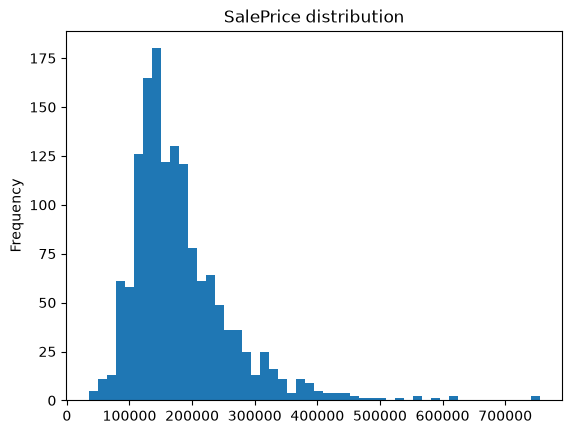

In [20]:
import numpy as np 
import pandas as pd 

houses=pd.read_csv('train.csv')
price=houses["SalePrice"]
print(price.describe())
price.plot(kind="hist",bins=50,title="SalePrice distribution")

In [21]:
Q1=price.quantile(0.25)  
Q3 = price.quantile( 0.75)  

IQR = Q3 - Q1  

lower_fence=Q1-1.5*IQR
upper_fence = Q3+1.5*IQR 

houses["outlier_iqr"] = (price <lower_fence) | (price > upper_fence) 

In [22]:
z = (price - price.mean()) / price.std(ddof=1) 

houses["outlier_zscore"] = z.abs() > 3 

In [23]:
med = price.median() 

mad = (price - med).abs().median() 
houses["outlier_robust_z"] = (0.6745 * (price - med) / mad).abs() > 3.5 

In [24]:
summary = houses[["outlier_iqr", "outlier_zscore", "outlier_robust_z"]].sum() 

print(summary) 

outlier_iqr         61
outlier_zscore      22
outlier_robust_z    51
dtype: int64


In [25]:
outliers = houses[houses["outlier_iqr"] | houses["outlier_robust_z"]] 

outliers[["SalePrice", "GrLivArea", "Neighborhood", "YearBuilt"]].sort_values("SalePrice") 

,SalePrice,GrLivArea,Neighborhood,YearBuilt
718,341000,2418,NoRidge,1993
320,342643,2596,NridgHt,2006
642,345000,2704,NAmes,1972
11,345000,2324,NridgHt,2005
990,348000,2392,NoRidge,1997
...,...,...,...,...
803,582933,2822,NridgHt,2008
898,611657,2364,NridgHt,2009
1169,625000,3627,NoRidge,1995
1182,745000,4476,NoRidge,1996


In [26]:
houses["SalePrice_log"] = np.log1p(price)                                  # tame the right skew 

houses["GrLivArea_capped"] = houses["GrLivArea"].clip( 

    upper=houses["GrLivArea"].quantile(0.99)                               # limit a few extreme areas 

) 

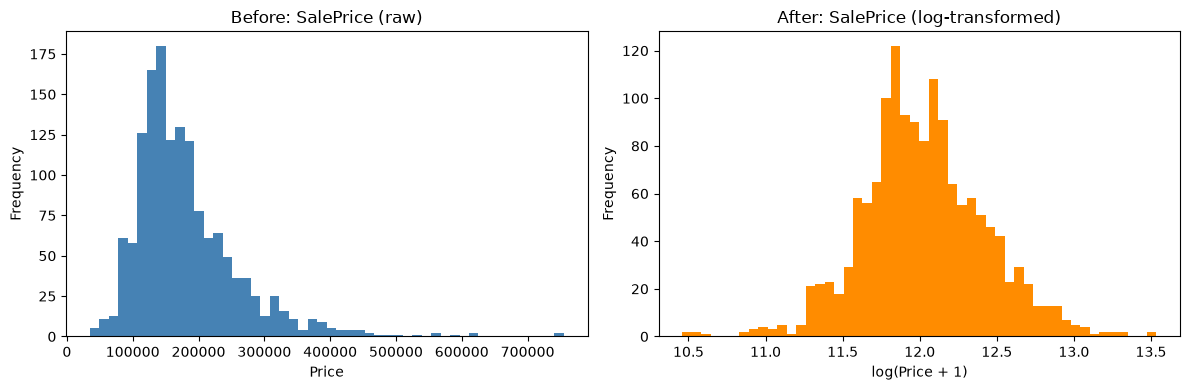

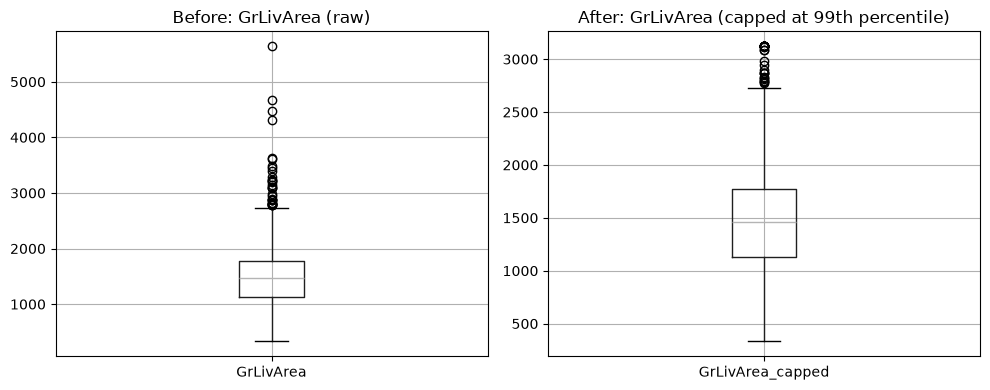

In [29]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

houses["SalePrice"].plot(kind="hist", bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Before: SalePrice (raw)")
axes[0].set_xlabel("Price")

houses["SalePrice_log"].plot(kind="hist", bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("After: SalePrice (log-transformed)")
axes[1].set_xlabel("log(Price + 1)")

plt.tight_layout()
plt.savefig("saleprice_before_after.png", dpi=150)
plt.show()



fig, axes = plt.subplots(1, 2, figsize=(10, 4))

houses.boxplot(column="GrLivArea", ax=axes[0])
axes[0].set_title("Before: GrLivArea (raw)")

houses.boxplot(column="GrLivArea_capped", ax=axes[1])
axes[1].set_title("After: GrLivArea (capped at 99th percentile)")

plt.tight_layout()
plt.savefig("grlivarea_before_after.png", dpi=150)
plt.show()